In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from quick_pp.objects import Project

# Load well from saved file
project_name = "VOLVE"
project_path = rf"data\04_project\{project_name}.qppp"
project = Project().load(project_path)
project.get_well_names()
all_data = project.get_all_data()

merged_core_df = pd.read_csv(r'data\merged_core_data.csv')

***
# Rock Typing

The process of rock typing is a multidisciplinary effort that involves close collaboration between geologists, petrophysicists, and reservoir engineers. Each discipline plays a specific role, and the rock typing workflow involves a seamless transition of data, models, and insights across these domains to build a robust understanding of the reservoir. Below is the high-level workflow detailing the steps, key tasks, and handoffs between these professionals

Petrophysicists take geological inputs and combine them with well log data and core analysis to define rock types based on petrophysical properties such as porosity, permeability, fluid saturation, and pore geometry.

Tasks:
- Core Data Integration:
    - Perform routine and special core analyses (RCAL, SCAL) to measure porosity, permeability, capillary pressure, and wettability.

- Log Interpretation:
    - Interpret wireline logs (e.g., density, neutron, resistivity, NMR) to generate continuous petrophysical properties along the wellbore.

- Rock Typing Methods:
    - Use statistical tools like Flow Zone Indicator (FZI), Pickett plots, and cluster analysis to group rocks with similar flow behavior into petrophysical rock types.

- Electrofacies Analysis:
    - Identify electrofacies by clustering log responses, especially where core data is limited.

The rock typing workflow is a collaborative process where geologists, petrophysicists, and reservoir engineers work together to ensure the reservoir is accurately characterized and modeled. This interdisciplinary approach ensures that both geological and petrophysical complexities are accounted for, resulting in more efficient production strategies and better field development plans

## Some of the different methods in Rock Typing

As a comparison, the core porosity and permeability are plotted and Winland R35 methods.

- The plot demonstrates Winland R35 resulted in a less drastic permeability estimation with respect to porosity.
- Lower porosity - high permeability datapoints:
    - These points might be the result of fractured cores.
    - Both Winland R35 and Lucia RFN does not model the datapoints.
    - FZI is able to model but indicates too high of a value.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

num_facies = 13
df_with_dummies = pd.get_dummies(all_data, columns=['LITHOFACIES'], prefix='FACIES')

# Define the features to be used for clustering
litho_cols = [c for c in df_with_dummies.columns if 'FACIES' in c]
cluster_features = ['GR', 'NPHI', 'RHOB']  + litho_cols

for well, data in df_with_dummies.groupby('WELL_NAME'):
    X_cluster = data[cluster_features]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cluster)

    imputer = KNNImputer(n_neighbors=9)
    X_imputed = imputer.fit_transform(X_scaled)

    # Initialize KMeans with x clusters
    kmeans = KMeans(n_clusters=num_facies, random_state=42, n_init='auto')
    all_data.loc[all_data.WELL_NAME == well, 'CLUSTER'] = kmeans.fit_predict(X_imputed)

all_data['CLUSTER'].value_counts()

In [ ]:
from quick_pp.rock_type import plot_fzi, plot_winland

plot_fzi(all_data['CPORE'], all_data['CPERM'], rock_type=all_data['CLUSTER'])
plot_winland(all_data['CPORE'], all_data['CPERM'], rock_type=all_data['CLUSTER'])

## FZI Rock Typing

### Identifying the number of rock types

Different methods have been discussed by previous works on determining of the number of rock types for a given core data. Among others are Wards Plot, Modified Lorenz Plot and its extensions.

1. Flow Zone Index (FZI) Method
    - The FZI method classifies rock types based on their flow characteristics. It involves calculating the Flow Zone Index from core data and using it to group similar rock types. This method is particularly effective in heterogeneous reservoirs3.

1. Ward’s Method
    - Ward’s method is a hierarchical clustering technique that minimizes the total within-cluster variance. It starts with each observation in its own cluster and merges clusters iteratively to minimize the increase in total within-cluster variance1. This method is particularly useful for quantitative variables and can be visualized using a dendrogram, which helps in identifying the optimal number of clusters (rock types).

2. Lorenz Method
    - The Lorenz method, often used in petrophysical analysis, involves plotting cumulative storage capacity against cumulative flow capacity. This method helps in identifying distinct rock types based on their flow properties. By analyzing the Lorenz plot, you can determine the number of rock types and their respective contributions to storage and flow capacities2.


As an example based on the Ward's plot below, the data can be grouped into 4 rock types where the limits of log(FZI) values are -0.679, -0.179, 1.71, 0.571 and 0.871.
This translates into FZI values of 0.209, 0.662, 1.483, 3.724, 7.43. Consequently, the rock types can be categorized as follows;
- Rock Type 1: FZI >= 3.724
- Rock Type 2: 1.483 <= FZI < 3.724
- Rock Type 3: 0.662 <= FZI < 1.483
- Rock Type 4: FZI < 0.662

In [ ]:
from quick_pp.rock_type import plot_cumulative_probability, plot_modified_lorenz
import json

clean_core_data = merged_core_df.dropna(subset=['CPORE', 'CPERM'])

log_fzi_cutoffs = [-0.084, .121, .316, .516, .615, .766, .961, 1.016, 1.100, 1.216, 1.32]
plot_cumulative_probability(clean_core_data['CPORE'], clean_core_data['CPERM'], cutoffs=log_fzi_cutoffs)
plot_modified_lorenz(clean_core_data['CPORE'], clean_core_data['CPERM'])

fzi_cutoffs = [round(10**(i), 3) for i in log_fzi_cutoffs]
print(fzi_cutoffs)
with open(rf'data\04_project\{project_name}\outputs\fzi_cutoffs.json', 'w') as file:
    json.dump(fzi_cutoffs, file)

In [ ]:
from quick_pp.rock_type import plot_fzi, calc_fzi, rock_typing, plot_ward_dendogram
from quick_pp.machine_learning.feature_engineering import gas_xover

all_data['GAS_XOVER'] = gas_xover(all_data.RHOB, all_data.NPHI)
all_data['LOG_RT'] = np.log10(all_data['RT'])

# Estimate rock types
fzi = calc_fzi(all_data['CPORE'], all_data['CPERM'])
all_data['FZI'] = fzi
fzi_rock_flag = rock_typing(fzi, fzi_cutoffs, higher_is_better=True)
all_data['ROCK_FLAG'] = fzi_rock_flag

plot_fzi(all_data['CPORE'], all_data['CPERM'], rock_type=fzi_rock_flag, cut_offs=fzi_cutoffs)
plot_ward_dendogram(all_data['FZI'], p=30)
print(pd.Series(fzi_rock_flag).value_counts().sort_index())

### Develop Machine Learning models to predict ROCK_FLAG and FZI

The models will then be used to predict the Rock Type and FZI at non-cored intervals

In [ ]:
from quick_pp.rock_type import train_classification_model, train_regression_model

train_data = all_data.copy()
input_features = ['VCLAY', 'PHIE', 'LOG_RT', 'GAS_XOVER']
train_data = train_data.dropna(subset=input_features + ['ROCK_FLAG', 'FZI'])

fzi_rt_model = train_classification_model(
    train_data, input_features=input_features, target_feature='ROCK_FLAG', stratifier=train_data['ROCK_FLAG'])
with open(rf'data\04_project\{project_name}\outputs\fzi_rt_model.qppm', 'wb') as file:
    pickle.dump(fzi_rt_model, file)

In [ ]:
train_data['ROCK_PRED'] = fzi_rt_model.predict(train_data[input_features])
input_features_fzi = input_features + ['ROCK_PRED']
train_data['LOG_FZI'] = np.log10(train_data['FZI'])
fzi_model = train_regression_model(
    train_data, input_features=input_features_fzi, target_feature='LOG_FZI', stratifier=train_data['ROCK_PRED'])
with open(rf'data\04_project\{project_name}\outputs\fzi_model.qppm', 'wb') as file:
    pickle.dump(fzi_model, file)

In [ ]:
predicted_fzi_rt = fzi_rt_model.predict(all_data[input_features])
plot_fzi(all_data['CPORE'], all_data['CPERM'], rock_type=predicted_fzi_rt, cut_offs=fzi_cutoffs)

In [ ]:
all_data['ROCK_PRED'] = fzi_rt_model.predict(all_data[input_features])

pred_data = all_data.dropna(subset=input_features_fzi)
predicted_fzi = 10**(fzi_model.predict(pred_data[input_features_fzi]))
predicted_fzi_rt = rock_typing(predicted_fzi, fzi_cutoffs, higher_is_better=True)
plot_fzi(pred_data['CPORE'], pred_data['CPERM'], rock_type=predicted_fzi_rt, cut_offs=fzi_cutoffs)

Comparing the predicted electrofacies with the clustered from lithofacies. The numbering of the clustered lithofacies is not following a particular order, thus it's mainly for comparing the cluster against the predicted values.

In [ ]:
plt.figure(figsize=(20, 3))
plt.scatter(all_data.DEPTH, all_data['ROCK_PRED'], label='pred rock')
plt.scatter(all_data.DEPTH, all_data['CLUSTER'], label='clustered')
plt.legend()

***
# Permeability Transform

### Determining the perm transform parameter for each rock type.

In [ ]:
from ipywidgets import interact, widgets

from quick_pp.core_calibration import poroperm_xplot

rt = widgets.Dropdown(
    options=sorted(all_data['ROCK_FLAG'].dropna().unique()),
    value=1,
    description='Rock Type:'
)
a = widgets.IntText(value=0, step=5000, description='a:')
b = widgets.FloatText(value=0, step=.1, description='b:')

@interact(rt=rt, a=a, b=b)
def param(rt, a, b):
    data = all_data.copy()
    group = np.where(all_data['ROCK_FLAG'] == rt, 0, 1)
    poroperm_xplot(data['CPORE'], data['CPERM'], core_group=group, a=a, b=b, label=f'RT{rt}:\n a={a:d},\n b={b:.2f}')

In [ ]:
import pprint

from quick_pp.core_calibration import fit_poroperm_curve

poroperm_params = {}

for rt, data in all_data.groupby('ROCK_FLAG'):
    a, b = fit_poroperm_curve(data['CPORE'], data['CPERM'])
    poroperm_params[rt] = (a, b)

pp = pprint.PrettyPrinter(indent=4)
pp.pprint(poroperm_params)

In [ ]:
# Update poroperm_params with user input if needed
# poroperm_params[rt.value] = (a.value, b.value)

plt.figure(figsize=(12, 8))
for rt, data in all_data.groupby('ROCK_FLAG'):
    a, b = poroperm_params[rt]
    poroperm_xplot(data['CPORE'], data['CPERM'], a=a, b=b, label=f'RT{rt}: a={a:1d}, b={b:.2f}')

In [ ]:
# Update poroperm_params with user input if needed
poroperm_params[1] = (int(1e7), 4.5)
poroperm_params[2] = (int(25e5), 4)

plt.figure(figsize=(12, 8))
for rt, data in all_data.groupby('ROCK_FLAG'):
    a, b = poroperm_params[rt]
    poroperm_xplot(data['CPORE'], data['CPERM'], a=a, b=b, label=f'RT{rt}: a={a:1d}, b={b:.2f}')

### Compare different PERM estimations at well level

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, r2_score

from quick_pp.core_calibration import perm_transform
from quick_pp.rock_type import calc_fzi_perm

focus_well = '15-9-19-A'
well_data = all_data[all_data.WELL_NAME == focus_well].copy()

# Permeability estimation based on core data perm transform
a = well_data['ROCK_FLAG'].map(poroperm_params).apply(lambda x: x[0] if type(x) == tuple else np.nan)
b = well_data['ROCK_FLAG'].map(poroperm_params).apply(lambda x: x[1] if type(x) == tuple else np.nan)
perm_trans = perm_transform(well_data['PHIE'], a=a, b=b)

# Permeability estimation based on FZI from core data
fzi = calc_fzi(well_data['CPORE'], well_data['CPERM'])
perm_fzi = calc_fzi_perm(fzi, well_data['PHIE'])

# Permeability prediction based on ROCK_FLAG ML model followed by perm transform
well_data['LOG_RT'] = np.log10(well_data['RT'])

with open(rf'data\04_project\{project_name}\outputs\fzi_rt_model.qppm', 'rb') as file:
    fzi_rt_model = pickle.load(file)
rock_flag_ml = fzi_rt_model.predict(well_data[input_features])
perm_a_ml = pd.Series(rock_flag_ml).map(poroperm_params).apply(lambda x: x[0] if type(x) == tuple else np.nan)
perm_b_ml = pd.Series(rock_flag_ml).map(poroperm_params).apply(lambda x: x[1] if type(x) == tuple else np.nan)
perm_ml = perm_transform(well_data['PHIE'], perm_a_ml, perm_b_ml)

# Permeability prediction based on FZI ML model followed by back calculate from FZI
well_data['ROCK_PRED'] = fzi_rt_model.predict(well_data[input_features])
with open(rf'data\04_project\{project_name}\outputs\fzi_model.qppm', 'rb') as file:
    fzi_model = pickle.load(file)
fzi_ml = 10**(fzi_model.predict(well_data[input_features_fzi].ffill().bfill()))
perm_fzi_ml = calc_fzi_perm(fzi_ml, well_data['PHIE'])

# Plot to compare
plt.figure(figsize=(20, 2))
plt.plot(well_data.DEPTH, perm_trans, label='Perm Transform')
plt.plot(well_data.DEPTH, perm_fzi, label='Perm FZI')
# plt.plot(well_data.DEPTH, perm_ml, label='Perm ML')
plt.plot(well_data.DEPTH, perm_fzi_ml, label='Perm FZI ML')
plt.scatter(well_data.DEPTH, well_data.CPERM, label='Core Perm', marker='.', c='black')
plt.yscale('log')
plt.legend()

### Compare different ROCK_FLAG at well level

In [ ]:
# Compare rock types predicted from rt_model with applied cut-offs on predicted r35
rock_flag_fzi_ml = rock_typing(fzi_ml, fzi_cutoffs, higher_is_better=True)

plt.figure(figsize=(20, 2))
plt.plot(well_data.DEPTH, well_data.ROCK_FLAG, label='Rock Flag Core')
plt.plot(well_data.DEPTH, rock_flag_ml, label='Rock Flag ML')
plt.plot(well_data.DEPTH, rock_flag_fzi_ml, label='Rock Flag FZI ML')
plt.legend()

***
# Plotting the result

In [ ]:
from quick_pp.plotter.plotter import plotly_log

# Plot individual results
well_data['PERM'] = perm_fzi_ml
fig = plotly_log(well_data, well_name=focus_well, depth_uom='m')
fig.show(config=dict(scrollZoom=True))

# Apply to all

In [ ]:
from sklearn.impute import SimpleImputer
import json

from quick_pp.machine_learning.feature_engineering import gas_xover
from quick_pp.rock_type import *

# Load FZI ROCK_FLAG
with open(rf'data\04_project\{project_name}\outputs\fzi_rt_model.qppm', 'rb') as file:
    fzi_rt_model = pickle.load(file)

# Load FZI model
with open(rf'data\04_project\{project_name}\outputs\fzi_model.qppm', 'rb') as file:
    fzi_model = pickle.load(file)

# Load FZI cutoffs
with open(rf'data\04_project\{project_name}\outputs\fzi_cutoffs.json', 'rb') as file:
    fzi_cutoffs = json.load(file)

imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')

input_features = ['VCLAY', 'PHIE', 'LOG_RT', 'GAS_XOVER']
input_features_fzi = input_features + ['ROCK_PRED']

df = project.get_all_data()
df['GAS_XOVER'] = gas_xover(df.RHOB, df.NPHI)
df['LOG_RT'] = np.log10(all_data['RT'])
for well_name, well_data in df.groupby('WELL_NAME'):

    rock_flag_ml = fzi_rt_model.predict(well_data[input_features])
    
    # Predict permeability
    temp_df = well_data.copy()
    temp_df['ROCK_PRED'] = rock_flag_ml
    temp_df[input_features] = imp_mean.fit_transform(temp_df[input_features])
    fzi_ml = 10**(fzi_model.predict(temp_df[input_features_fzi]))
    perm_ml = calc_fzi_perm(fzi_ml, well_data['PHIE']).clip(lower=1e-3)

    # Update rock type
    rock_flag_ml = rock_typing(fzi_ml, cut_offs=fzi_cutoffs)

    well_data['PERM'] = perm_ml
    well_data['ROCK_FLAG'] = rock_flag_ml    

    # Save the well data
    project.update_data(well_data)
project.save()

In [ ]:
df = project.get_all_data()
score_df = df[['WELL_NAME', 'CPERM', 'PERM']].copy()
score_df.dropna(inplace=True)
mape = round(mean_absolute_percentage_error(score_df.CPERM, score_df.PERM), 2)
r2 = round(r2_score(score_df.CPERM, score_df.PERM), 2)
print(f"\n ### PERM MAPE: {mape:.2f}")
print(f" ### PERM R2: {r2:.2f}")

plt.scatter(score_df.CPERM, score_df.PERM, label=f'Overall - R2: {r2}, MAPE: {mape}')
for well, data in score_df.groupby('WELL_NAME'):
    mape = round(mean_absolute_percentage_error(data.CPERM, data.PERM), 2)
    r2 = round(r2_score(data.CPERM, data.PERM), 2)
    plt.scatter(data.CPERM, data.PERM, label=f'{well} - R2: {r2}, MAPE: {mape}')
plt.xlabel('Actual')
plt.ylabel('Calculated')
plt.xlim(1e-2, 1e5)
plt.ylim(1e-2, 1e5)
plt.loglog()
plt.legend()

AttributeError: 'DataFrame' object has no attribute 'PERM'

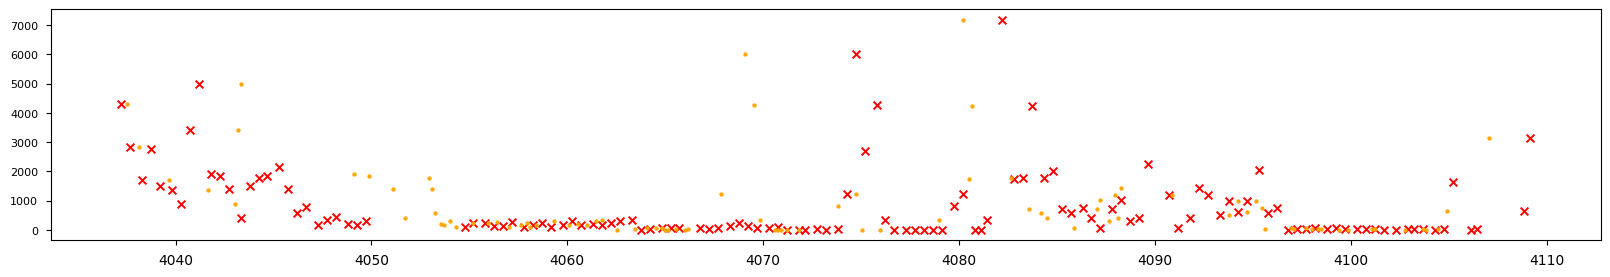

In [ ]:
copy_df = df[df.WELL_NAME == '15-9-19-BT2']
plt.figure(figsize=(20, 3))
plt.scatter(copy_df.DEPTH, copy_df.CPERM, marker='x', c='red', label='CPERM ORI')
plt.scatter(copy_df.DEPTH, copy_df.CPERM_SHIFTED, marker='.', c='orange', label='CPERM SHIFTED')
plt.plot(copy_df.DEPTH, copy_df.PERM, 'b--', label='PERM')
plt.legend()
plt.ylim(1e-2, 1e4)
plt.yscale('log')
plt.xlim(4035, 4110)